In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from urllib.parse import urlparse
import math

DATA_PATH = r"E:\file_main\Major_2\data\processed\phishing_urls_final.csv"
df = pd.read_csv(DATA_PATH)

df.head()


,url,label
0,https://wiercommercialconstruction.myportfolio...,1
1,https://l.ead.me/bfjdph,1
2,https://www.urbanluminariadesign.cfd,0
3,https://l.ead.me/bfwf4a,1
4,https://www.clickbond.com,0


In [4]:
df.info()
df["label"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91652 entries, 0 to 91651
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     91652 non-null  object
 1   label   91652 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.4+ MB


label
1    46652
0    45000
Name: count, dtype: int64

In [6]:
def url_length(url):
    return len(url)

def count_digits(url):
    return sum(char.isdigit() for char in url)

def count_special_chars(url):
    return sum(not char.isalnum() for char in url)

def count_dots(url):
    return url.count('.')

def has_at_symbol(url):
    return int('@' in url)

def entropy(url):
    probs = [url.count(c) / len(url) for c in set(url)]
    return -sum(p * math.log2(p) for p in probs)

In [7]:
df["url_length"] = df["url"].apply(url_length)
df["digits"] = df["url"].apply(count_digits)
df["special_chars"] = df["url"].apply(count_special_chars)
df["dots"] = df["url"].apply(count_dots)
df["has_at"] = df["url"].apply(has_at_symbol)
df["entropy"] = df["url"].apply(entropy)

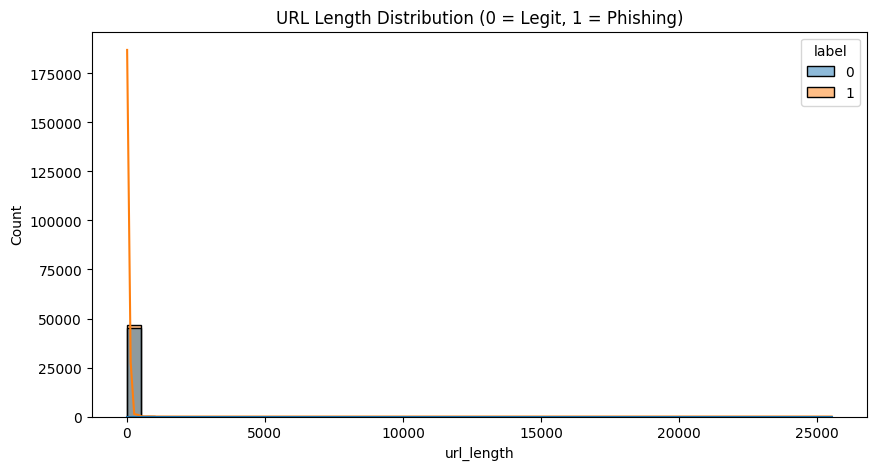

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df, x="url_length", hue="label", bins=50, kde=True)
plt.title("URL Length Distribution (0 = Legit, 1 = Phishing)")
plt.show()

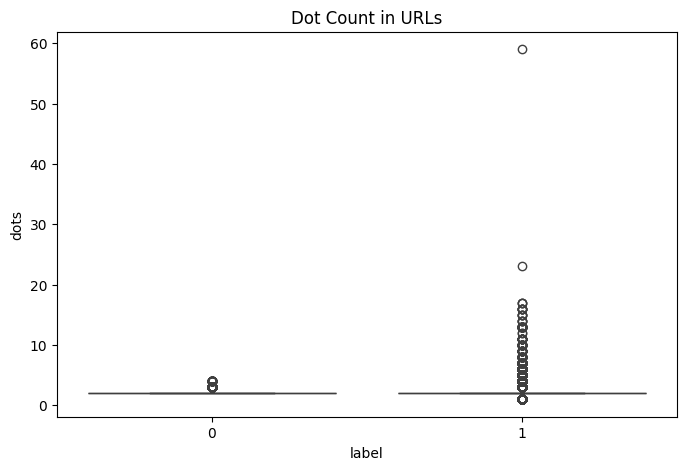

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="dots", data=df)
plt.title("Dot Count in URLs")
plt.show()

In [21]:
df.groupby("label")["has_at"].mean()

label
0    0.000000
1    0.009646
Name: has_at, dtype: float64

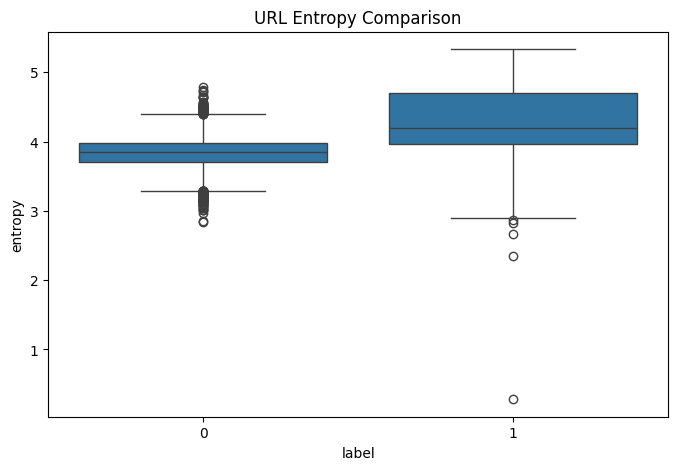

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="entropy", data=df)
plt.title("URL Entropy Comparison")
plt.show()

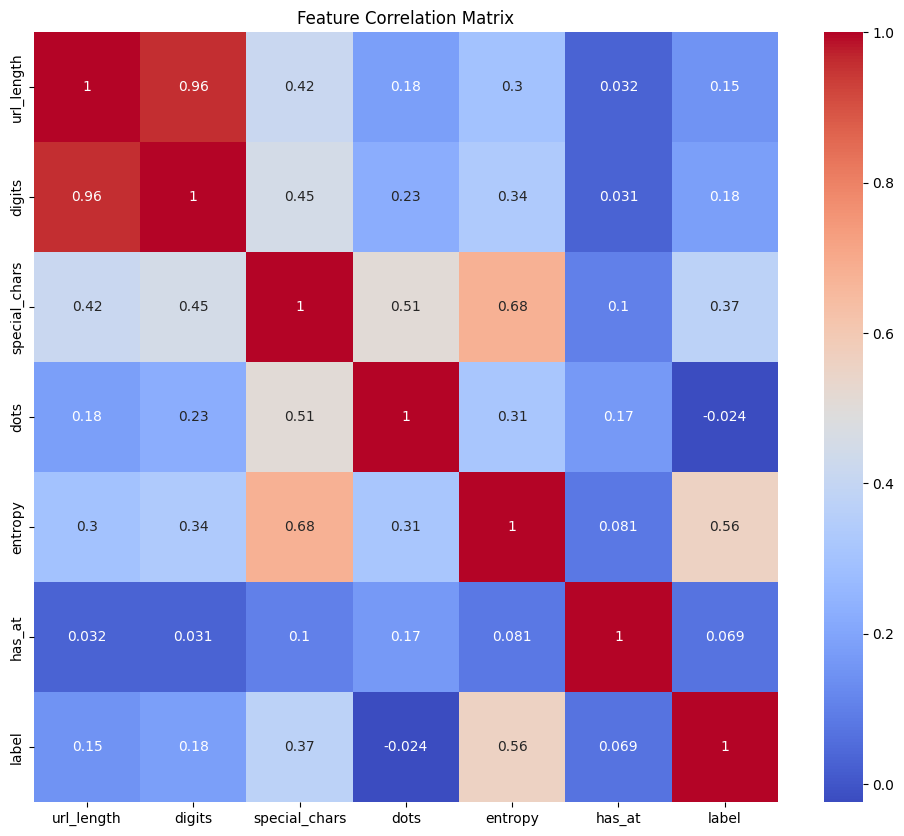

In [25]:
corr = df[
    ["url_length", "digits", "special_chars", "dots", "entropy", "has_at", "label"]
].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()
